# Desarrollo de Entrega Unidad 4 – Base de Datos de tienda usando las Unidades 9 y 10

En este caso trabajaremos con una base de datos de órdenes de bases de datos de tienda de la unidad 4.

Iniciemos importando las librerías necesarias

In [7]:
#!conda install sklearn -y
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
import plotly.express as px
import plotly.graph_objects as go

# Cargando y Analizando la Base de datos
Ahora importamos nuestra base de datos

In [8]:
consumer_data = pd.read_excel('data/Online Retail.xlsx')
consumer_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Cambiar los nombres de la base de datos creando un directorio 

In [9]:
from os import rename
consumer_data.rename(columns={'InvoiceNo':'Numero_factura','StockCode':'Cod_prod','Description':'Nombre_Producto','Quantity':'Cantidad','UnitPrice':'Precio unitario','InvoiceDate':'Fecha_compra','CustomerID':'Cod_Cliente','Country':'País'},inplace=True)
#consumer_data = pd.DataFrame(consumer_dat["Numero_factura"].astype(str))
#consumer_data.to_csv('data/Online_Retail.csv')
consumer_data

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Se analiza la estadistica de las variables númericas

In [10]:

consumer_data.describe()

,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Tipo de datos que se tienen

In [11]:
consumer_data.dtypes

Numero_factura             object
Cod_prod                   object
Nombre_Producto            object
Cantidad                    int64
Fecha_compra       datetime64[us]
Precio unitario           float64
Cod_Cliente               float64
País                          str
dtype: object

In [12]:
print('Cantidad de paises: ', consumer_data['País'].nunique())
print('Cantidad de productos: ', consumer_data['Cod_prod'].nunique())
print('Cantidad de usuarios: ', consumer_data['Cod_Cliente'].nunique())

Cantidad de paises:  38
Cantidad de productos:  4070
Cantidad de usuarios:  4372


C:\Users\adolp\AppData\Local\Temp\ipykernel_35348\1810569295.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=paises_ordenes.values, y=paises_traducidos, palette='viridis',color='goldenrod')


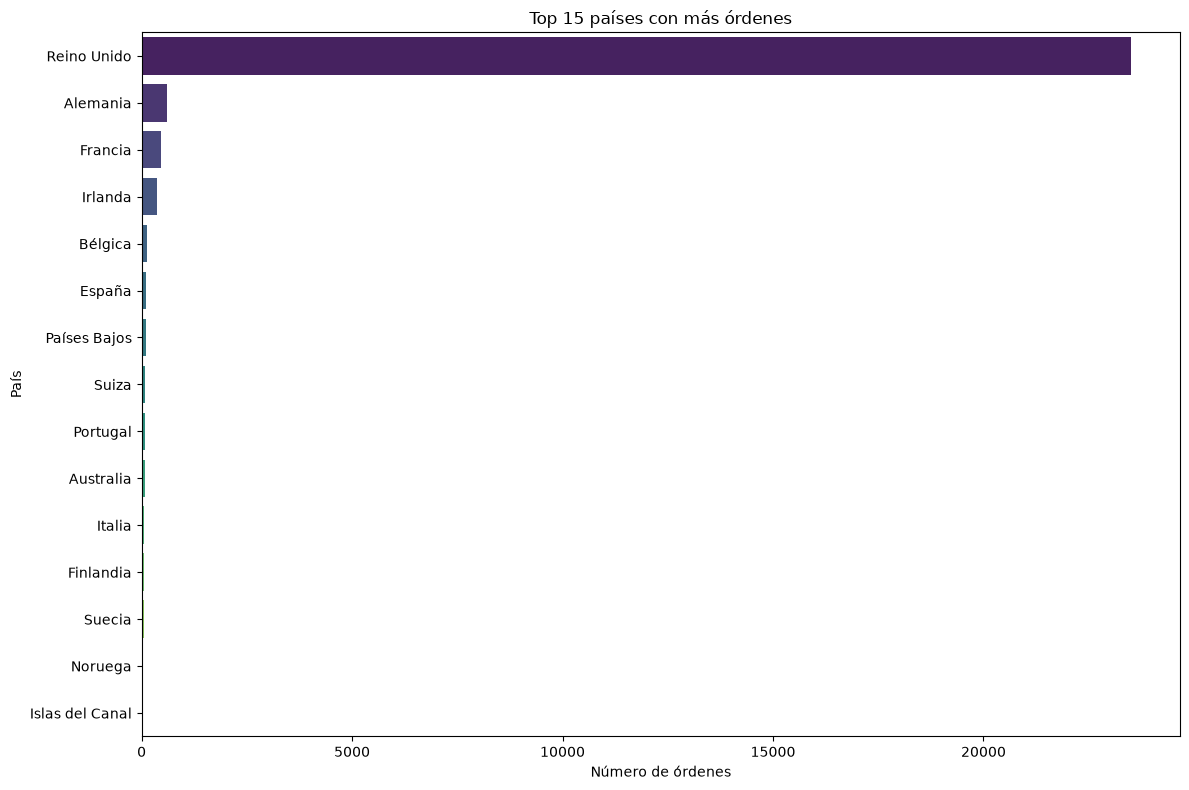

In [13]:
# Gráfica de órdenes por país con nombres en español
paises_ordenes = consumer_data.groupby('País')['Numero_factura'].nunique().sort_values(ascending=False).head(15)

traduccion_paises = {
    'United Kingdom': 'Reino Unido',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'Poland': 'Polonia',
    'Netherlands': 'Países Bajos',
    'Belgium': 'Bélgica',
    'Switzerland': 'Suiza',
    'Portugal': 'Portugal',
    'Australia': 'Australia',
    'Norway': 'Noruega',
    'EIRE': 'Irlanda',
    'Sweden': 'Suecia',
    'Denmark': 'Dinamarca',
    'Finland': 'Finlandia',
    'Italy': 'Italia',
    'Channel Islands': 'Islas del Canal',
    'Cyprus': 'Chipre',    
}

paises_traducidos = [traduccion_paises.get(p, p) for p in paises_ordenes.index]

plt.figure(figsize=(12, 8))
sns.barplot(x=paises_ordenes.values, y=paises_traducidos, palette='viridis',color='goldenrod')
plt.title('Top 15 países con más órdenes')
plt.xlabel('Número de órdenes')
plt.ylabel('País')
plt.tight_layout()
plt.show()

C:\Users\adolp\AppData\Local\Temp\ipykernel_35348\1335188669.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_mas_vendidos.values, y=productos_mas_vendidos.index, palette='coolwarm')


NameError: name 'axes' is not defined

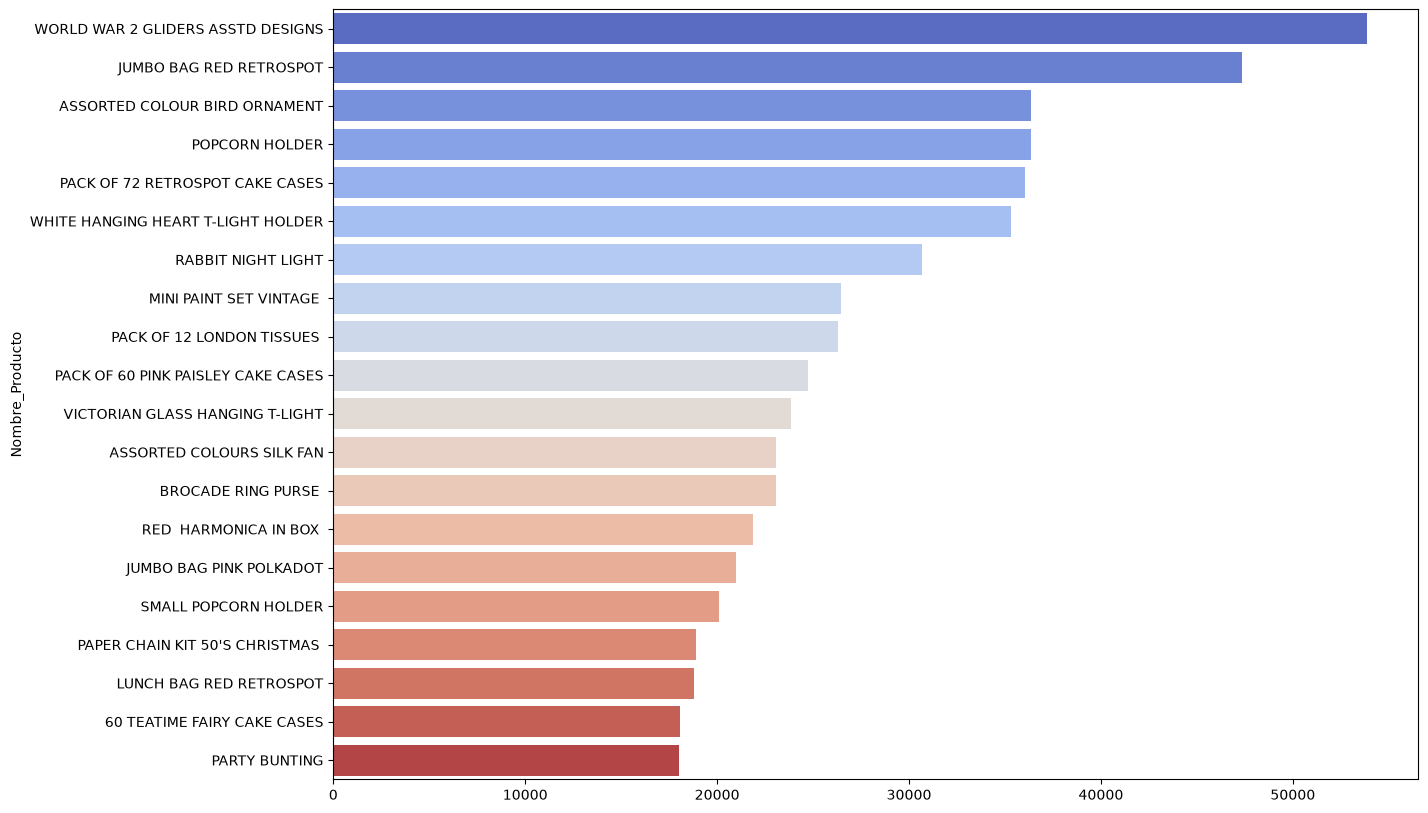

In [14]:
# Gráfica de productos más vendidos
productos_mas_vendidos = (
    consumer_data.groupby('Nombre_Producto')['Cantidad']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 10))
sns.barplot(x=productos_mas_vendidos.values, y=productos_mas_vendidos.index, palette='coolwarm')
axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3, fontsize=8)
axes[1].bar_label(axes[1].containers[0], fmt='%.0f', padding=3)

plt.title('Top 20 productos por cantidad vendida')
plt.xlabel('Cantidad total vendida')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

Verifiquemos si tenemos valores faltantes en nuestra base de datos

In [ ]:
consumer_data.isna().sum()

Numero_factura          0
Cod_prod                0
Nombre_Producto      1454
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64

# Tratamiento de la base de Datos
Teniendo en cuenta el código del producto se rellenaran los espacios

In [ ]:
def completar_nombres_productos(df):
    """
    Rellena los espacios en blanco (valores nulos) de la columna 'Nombre_Producto' 
    buscando el nombre asociado a su 'Cod_prod' en el resto del DataFrame.
    """
    # 1. Creamos un mapeo (diccionario) de Cod_prod -> Nombre_Producto
    # Descartamos los nulos y nos quedamos con la primera aparición de cada producto
    mapeo_nombres = (
        df[['Cod_prod', 'Nombre_Producto']]
        .dropna(subset=['Nombre_Producto'])
        .drop_duplicates(subset=['Cod_prod'])
        .set_index('Cod_prod')['Nombre_Producto']
    )
    
    # 2. Rellenamos los valores nulos en 'Nombre_Producto' usando la función map() 
    # que busca el Cod_prod en nuestro mapeo
    df['Nombre_Producto'] = df['Nombre_Producto'].fillna(df['Cod_prod'].map(mapeo_nombres))
    
    return df

# funcion adicional 


# Ejemplo de uso con tu DataFrame:
consumer_data = completar_nombres_productos(consumer_data)

# Para verificar que funcionó (opcional):
print("Valores nulos en 'Nombre_Producto':", consumer_data['Nombre_Producto'].isnull().sum())


Valores nulos en 'Nombre_Producto': 112


Verificamos el resultado

In [ ]:
consumer_data.isna().sum()

Numero_factura          0
Cod_prod                0
Nombre_Producto       112
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64

In [ ]:
consumer_data

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Tener pendiente consumer_data_a para el analisis de algoritmos no descriptivos

In [ ]:

# Reemplazar celdas vacías en Cod_Cliente por NaN
consumer_data_a = consumer_data.copy()
consumer_data_a['Cod_Cliente'] = consumer_data_a['Cod_Cliente'].replace(['', ' ', np.nan], np.nan)

# Mostrar el conteo de valores NaN después del reemplazo
print("Valores NaN después del reemplazo:")
print(consumer_data_a.isna().sum())
#print("\nValores únicos en Cod_Cliente (primeros 10):")
#print(consumer_data_a['Cod_Cliente'].unique()[:10])

Valores NaN después del reemplazo:
Numero_factura          0
Cod_prod                0
Nombre_Producto       112
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64


In [ ]:
# Reemplazar valores vacíos en Cod_Cliente por NaN y eliminar filas de consumer_data
consumer_data['Cod_Cliente'] = consumer_data['Cod_Cliente'].replace(['', ' '], np.nan)

filas_antes = len(consumer_data)
filas_vacias = consumer_data['Cod_Cliente'].isna().sum()
print(f"Número de filas antes de eliminar: {filas_antes}")
print(f"Filas con Cod_Cliente vacío: {filas_vacias}")

# Eliminar filas con Cod_Cliente vacío en consumer_data
consumer_data = consumer_data.dropna(subset=['Cod_Cliente']).reset_index(drop=True)
filas_despues = len(consumer_data)
print(f"\nNúmero de filas después de eliminar: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas vacías restantes en Cod_Cliente: {consumer_data['Cod_Cliente'].isna().sum()}")

Número de filas antes de eliminar: 541909
Filas con Cod_Cliente vacío: 135080



Número de filas después de eliminar: 406829
Filas eliminadas: 135080
Filas vacías restantes en Cod_Cliente: 0


# Eliminar los datos duplicados 

In [ ]:
print(f"consumer_data — filas antes: {len(consumer_data)}")
print(f"Duplicados exactos encontrados: {consumer_data.duplicated().sum()}")
consumer_data = consumer_data.drop_duplicates().reset_index(drop=True)
print(f"consumer_data — filas después: {len(consumer_data)}")

print(f"\nconsumer_data_a — filas antes: {len(consumer_data_a)}")
print(f"Duplicados exactos encontrados: {consumer_data_a.duplicated().sum()}")
consumer_data_a = consumer_data_a.drop_duplicates().reset_index(drop=True)
print(f"consumer_data_a — filas después: {len(consumer_data_a)}")

consumer_data — filas antes: 406829
Duplicados exactos encontrados: 5225
consumer_data — filas después: 401604

consumer_data_a — filas antes: 541909
Duplicados exactos encontrados: 5268
consumer_data_a — filas después: 536641


# Anexando una columna de estado de la compraer eincluye la columna monto para luego hacer analisisq

In [ ]:
consumer_data['Monto'] = consumer_data['Cantidad'] * consumer_data['Precio unitario']
consumer_data_a['Monto'] = consumer_data_a['Cantidad'] * consumer_data_a['Precio unitario']

consumer_data[['Cantidad', 'Precio unitario', 'Monto']].describe()

,Cantidad,Precio unitario,Monto
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,20.613638
std,250.283037,69.764035,430.352218
min,-80995.000000,0.000000,-168469.600000
25%,2.000000,1.250000,4.250000
50%,5.000000,1.950000,11.700000
75%,12.000000,3.750000,19.800000
max,80995.000000,38970.000000,168469.600000


Anexando una columna de estado de la compra

In [ ]:
def asignar_estado_compra(df):
    """
    Crea una nueva columna 'Estado de la compra'.
    Si el 'Numero_factura' contiene la letra 'C', se marca como 'Cancelado', 
    de lo contrario se marca como 'Realizado'.
    """
    # 1. Nos aseguramos de tratar la columna Numero_factura como texto (string)
    # 2. Comprobamos si contiene la letra 'C' (case=False para que no distinga entre mayúsculas y minúsculas)
    condicion_cancelado = df['Numero_factura'].astype(str).str.contains('C', case=False, na=False)
    
    # 3. np.where funciona así: np.where(condicion, valor_si_verdadero, valor_si_falso)
    df['Estado de la compra'] = np.where(condicion_cancelado, 'Cancelado', 'Realizado')
    
    return df
# Ejemplo de uso con tu DataFrame:
consumer_data = asignar_estado_compra(consumer_data)
# Para verificar que funcionó viendo algunas filas canceladas:
display(consumer_data[consumer_data['Estado de la compra'] == 'Cancelado'].head())

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Monto,Estado de la compra
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,Cancelado
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,Cancelado
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,Cancelado
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Cancelado
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Cancelado


Se adiciona la linea para trasformar la columna Numero de Factura a tipo texto.  

In [ ]:
consumer_data["Numero_factura"] = consumer_data["Numero_factura"].astype(str)
consumer_data["Cod_prod"] = consumer_data["Cod_prod"].astype(str)
consumer_data["Nombre_Producto"] = consumer_data["Nombre_Producto"].astype(str)
consumer_data


,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Monto,Estado de la compra
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Realizado
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Realizado
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado
...,...,...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,Realizado
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,Realizado
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado


Se realiza una la priemra grafica

se agrega las columnas fecha día mes hora

In [ ]:
# 2. Creamos las nuevas columnas extrayendo la información
dias_semana = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles',
    3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
#consumer_data['Dia_compra'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_semana)

consumer_data['Mes_compra'] = consumer_data['Fecha_compra'].dt.month
meses_mapping = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
consumer_data['Mes_compra'] = consumer_data['Mes_compra'].map(meses_mapping)
consumer_data['Mes_compra'] = pd.Categorical(
    consumer_data['Mes_compra'],
    categories=list(meses_mapping.values()),
    ordered=True
)
consumer_data['Hora_compra'] = consumer_data['Fecha_compra'].dt.hour
# Para verificar que las columnas se crearon correctamente:
display(consumer_data[['Fecha_compra', 'Mes_compra', 'Hora_compra']].head())
consumer_data

,Fecha_compra,Mes_compra,Hora_compra
0,2010-12-01 08:26:00,Diciembre,8
1,2010-12-01 08:26:00,Diciembre,8
2,2010-12-01 08:26:00,Diciembre,8
3,2010-12-01 08:26:00,Diciembre,8
4,2010-12-01 08:26:00,Diciembre,8


,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Monto,Estado de la compra,Mes_compra,Hora_compra
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Realizado,Diciembre,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado,Diciembre,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Realizado,Diciembre,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado,Diciembre,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Realizado,Diciembre,8
...,...,...,...,...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,Realizado,Diciembre,12
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,Realizado,Diciembre,12
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado,Diciembre,12
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,Realizado,Diciembre,12


<Axes: xlabel='Mes_compra'>

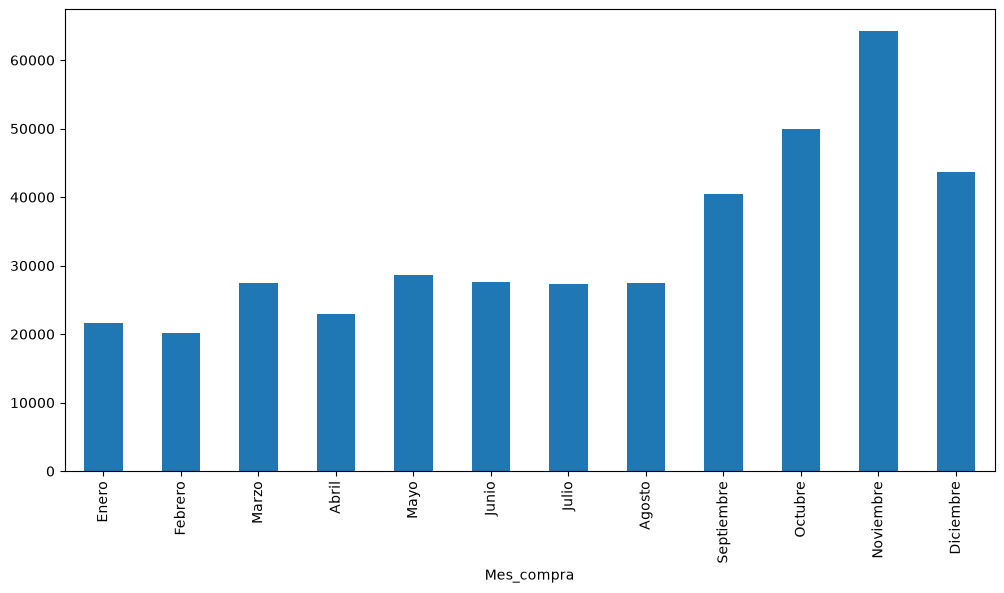

In [ ]:
#consumer_data = consumer_data.order(columns={'1': 'Enero', '2': 'Febrero', '3': 'Marzo', '4': 'Abril', '5': 'Mayo', '6': 'Junio', '7': 'Julio', '8': 'Agosto', '9': 'Septiembre', '10': 'Octubre', '11': 'Noviembre', '12': 'Diciembre'})
consumer_data['Mes_compra'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))


In [ ]:
consumer_data.describe()

,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,Monto,Hora_compra
count,401604.000000,401604,401604.000000,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818,20.613638,12.731031
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000,6.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000,11.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000,13.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,19.800000,14.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,20.000000
std,250.283037,NaN,69.764035,1714.006089,430.352218,2.288211


se vuelve a ver que tipo de datos que tiene la base 

In [ ]:
consumer_data.dtypes

Numero_factura                    str
Cod_prod                          str
Nombre_Producto                   str
Cantidad                        int64
Fecha_compra           datetime64[us]
Precio unitario               float64
Cod_Cliente                   float64
País                              str
Monto                         float64
Estado de la compra               str
Mes_compra                   category
Hora_compra                     int32
dtype: object

In [ ]:
#consumer_data['Dia_compra'].order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
#consumer_data['Dia_compra'].value_counts().reindex(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']).plot(kind='bar', figsize=(12, 6))
consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.day_name()

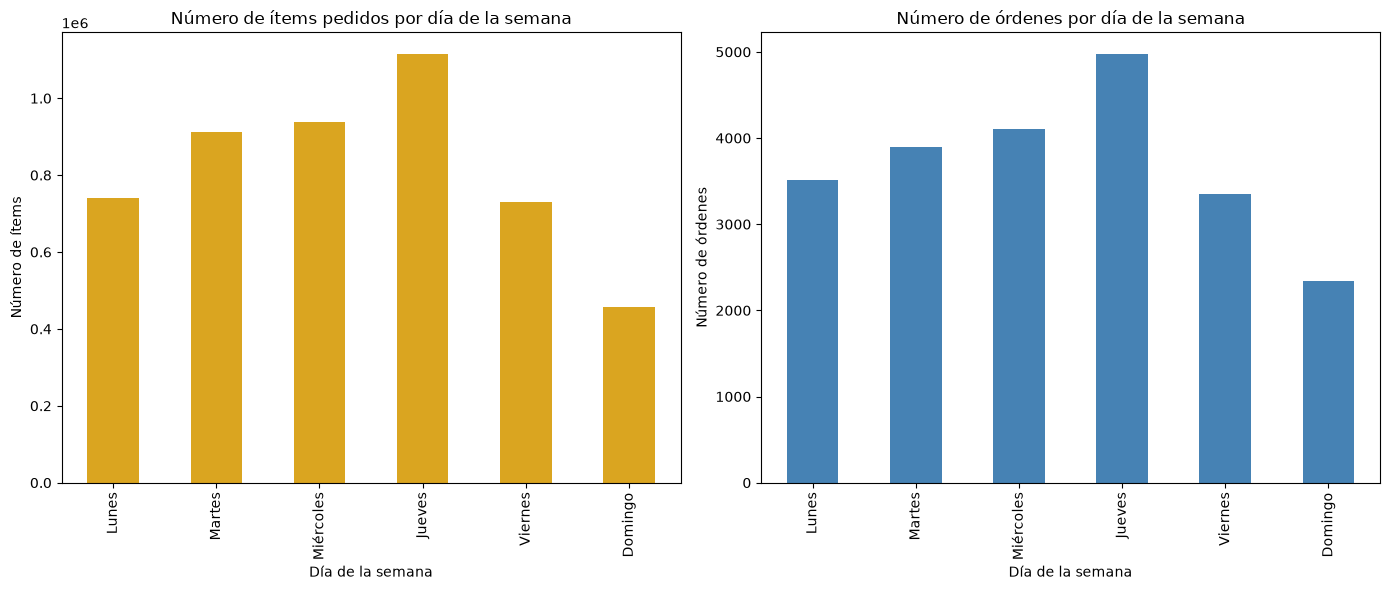

In [ ]:
# 1. Crear la columna de día de la semana (en español, ordenada Lunes->Domingo)
dias_es = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}
consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_es)
orden_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
consumer_data['Dia_semana'] = pd.Categorical(consumer_data['Dia_semana'], categories=orden_dias, ordered=True)

# 2. Agregaciones correctas por día de la semana
items_por_dia = consumer_data.groupby('Dia_semana')['Cantidad'].sum()
ordenes_por_dia = consumer_data.groupby('Dia_semana')['Numero_factura'].nunique()

# 3. Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

items_por_dia.plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Número de ítems pedidos por día de la semana')
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylabel('Número de ítems')

ordenes_por_dia.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Número de órdenes por día de la semana')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.show()

# Grafico de los paises a los cuales se envia los articulos 

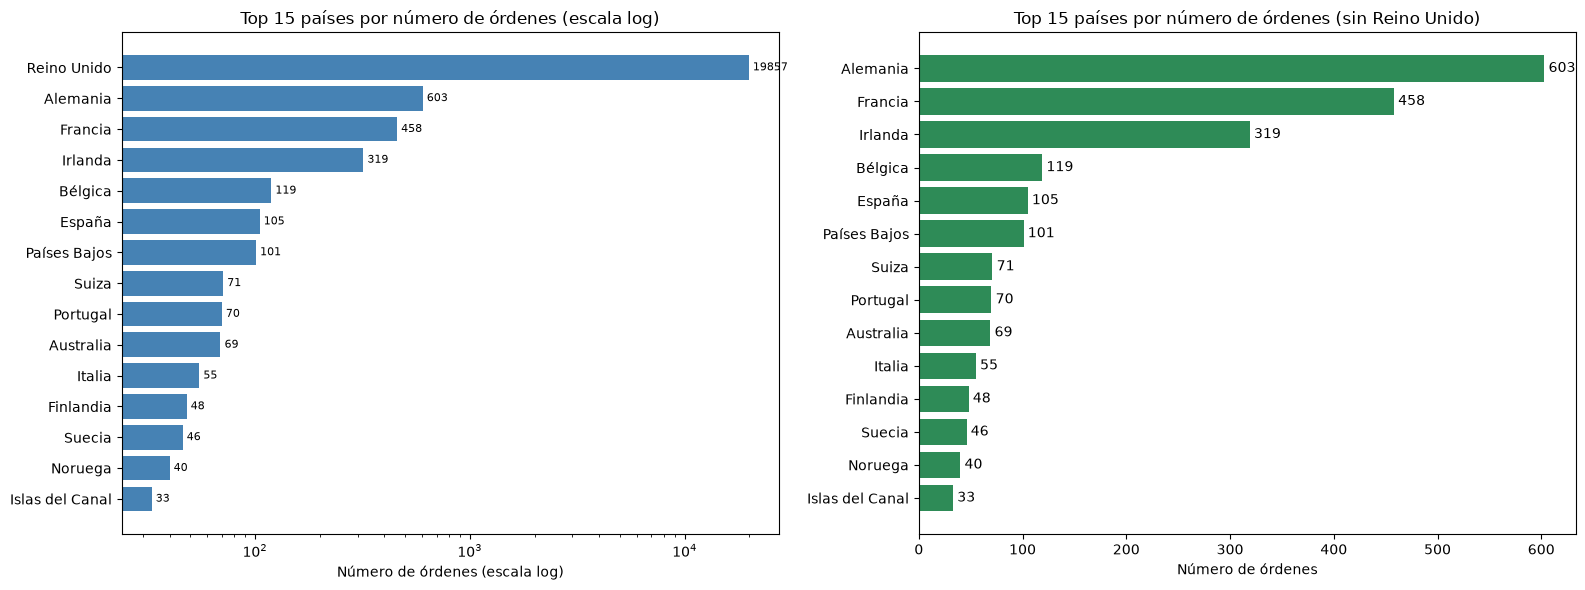

In [ ]:

# Métrica correcta: facturas únicas, no filas
traduccion_paises = {
    'United Kingdom': 'Reino Unido',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'Poland': 'Polonia',
    'Netherlands': 'Países Bajos',
    'Belgium': 'Bélgica',
    'Switzerland': 'Suiza',
    'Portugal': 'Portugal',
    'Australia': 'Australia',
    'Norway': 'Noruega',
    'EIRE': 'Irlanda',
    'Sweden': 'Suecia',
    'Denmark': 'Dinamarca',
    'Finland': 'Finlandia',
    'Italy': 'Italia',
    'Channel Islands': 'Islas del Canal',
    'Cyprus': 'Chipre',    
}

ordenes_por_pais = consumer_data.groupby('País')['Numero_factura'].nunique().sort_values(ascending=False)
top15 = ordenes_por_pais.head(15)
top15.index = [traduccion_paises.get(p, p) for p in top15.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[0].set_xscale('log')

axes[1].barh(top15_sin_uk.index[::-1], top15_sin_uk.values[::-1], color='seagreen')

axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3, fontsize=8)
axes[1].bar_label(axes[1].containers[0], fmt='%.0f', padding=3)

axes[0].set_title('Top 15 países por número de órdenes (escala log)')
axes[0].set_xlabel('Número de órdenes (escala log)')

top15_sin_uk = top15.drop('Reino Unido', errors='ignore')
axes[1].barh(top15_sin_uk.index[::-1], top15_sin_uk.values[::-1], color='seagreen')
axes[1].set_title('Top 15 países por número de órdenes (sin Reino Unido)')
axes[1].set_xlabel('Número de órdenes')

plt.tight_layout()
plt.show()


Analisis de Hora del día

C:\Users\adolp\AppData\Local\Temp\ipykernel_22624\1801127518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values, palette='mako')


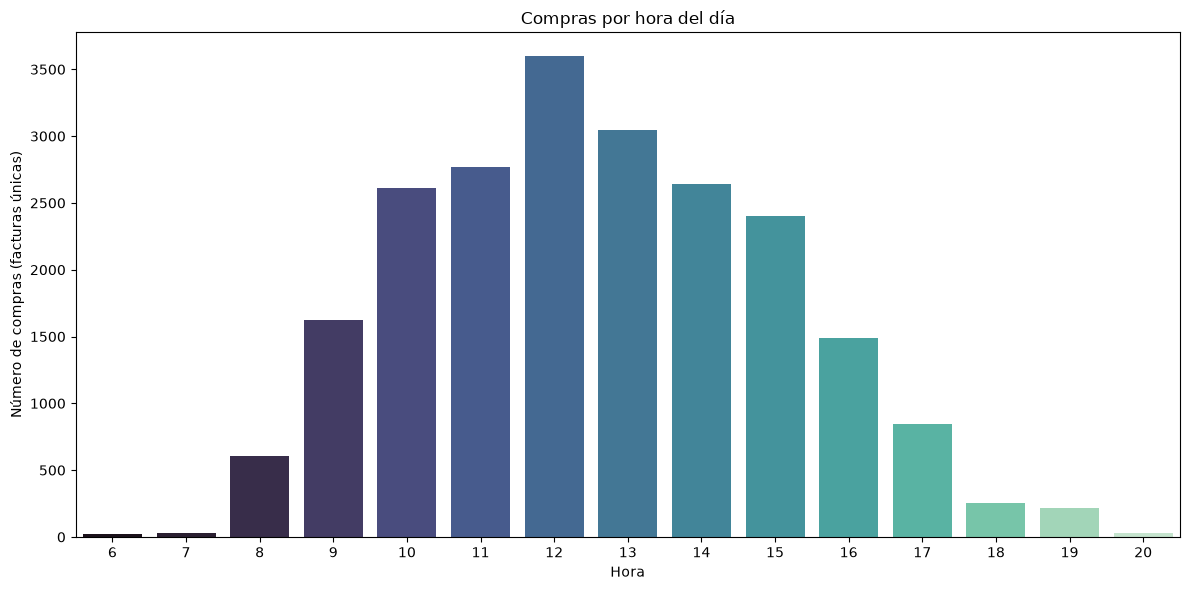

In [ ]:
# Gráfico de compras por hora del día
compras_por_hora = consumer_data.groupby('Hora_compra')['Numero_factura'].nunique().sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values, palette='mako')
plt.title('Compras por hora del día')
plt.xlabel('Hora')
plt.ylabel('Número de compras (facturas únicas)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Analisis de compras por producto y pais

In [ ]:
producto_mas = pd.crosstab(consumer_data['Dia_semana'], consumer_data['Nombre_Producto'])
producto_mas

Nombre_Producto,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Dia_semana,,,,,,,,,,,,,,,,,,,,,
Lunes,6,22,10,8,0,6,9,19,32,21,...,0,2,10,29,2,43,0,31,2,2
Martes,6,16,20,9,0,3,10,13,30,29,...,0,6,15,24,0,44,1,32,1,3
Miércoles,8,16,23,15,0,5,12,14,43,29,...,0,1,15,24,0,42,3,38,2,4
Jueves,2,26,37,14,1,7,10,23,45,32,...,1,5,16,27,0,50,5,32,5,8
Viernes,4,16,24,12,0,4,7,12,27,19,...,0,1,8,26,0,30,2,25,1,2
Domingo,11,14,23,11,0,5,15,11,23,15,...,0,4,15,21,0,32,0,34,1,1


In [ ]:
producto_mas.idxmax(axis=1)

Dia_semana
Lunes                  REGENCY CAKESTAND 3 TIER
Martes       WHITE HANGING HEART T-LIGHT HOLDER
Miércoles    WHITE HANGING HEART T-LIGHT HOLDER
Jueves                 REGENCY CAKESTAND 3 TIER
Viernes                REGENCY CAKESTAND 3 TIER
Domingo      WHITE HANGING HEART T-LIGHT HOLDER
dtype: str

Se realiza pivot_table

In [ ]:
producto_mas = consumer_data.pivot_table(index='Nombre_Producto', columns='Dia_semana', aggfunc='size', fill_value=0)
producto_mas.head(6)


Dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Domingo
Nombre_Producto,,,,,,
4 PURPLE FLOCK DINNER CANDLES,6,6,8,2,4,11
50'S CHRISTMAS GIFT BAG LARGE,22,16,16,26,16,14
DOLLY GIRL BEAKER,10,20,23,37,24,23
I LOVE LONDON MINI BACKPACK,8,9,15,14,12,11
I LOVE LONDON MINI RUCKSACK,0,0,0,1,0,0
NINE DRAWER OFFICE TIDY,6,3,5,7,4,5


In [ ]:
producto_mas =producto_mas.div(producto_mas.sum(axis=1), axis=0)
producto_mas.head(20)

Dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Domingo
Nombre_Producto,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0.162162,0.162162,0.216216,0.054054,0.108108,0.297297
50'S CHRISTMAS GIFT BAG LARGE,0.200000,0.145455,0.145455,0.236364,0.145455,0.127273
DOLLY GIRL BEAKER,0.072993,0.145985,0.167883,0.270073,0.175182,0.167883
I LOVE LONDON MINI BACKPACK,0.115942,0.130435,0.217391,0.202899,0.173913,0.159420
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
NINE DRAWER OFFICE TIDY,0.200000,0.100000,0.166667,0.233333,0.133333,0.166667
OVAL WALL MIRROR DIAMANTE,0.142857,0.158730,0.190476,0.158730,0.111111,0.238095
RED SPOT GIFT BAG LARGE,0.206522,0.141304,0.152174,0.250000,0.130435,0.119565
SET 2 TEA TOWELS I LOVE LONDON,0.160000,0.150000,0.215000,0.225000,0.135000,0.115000


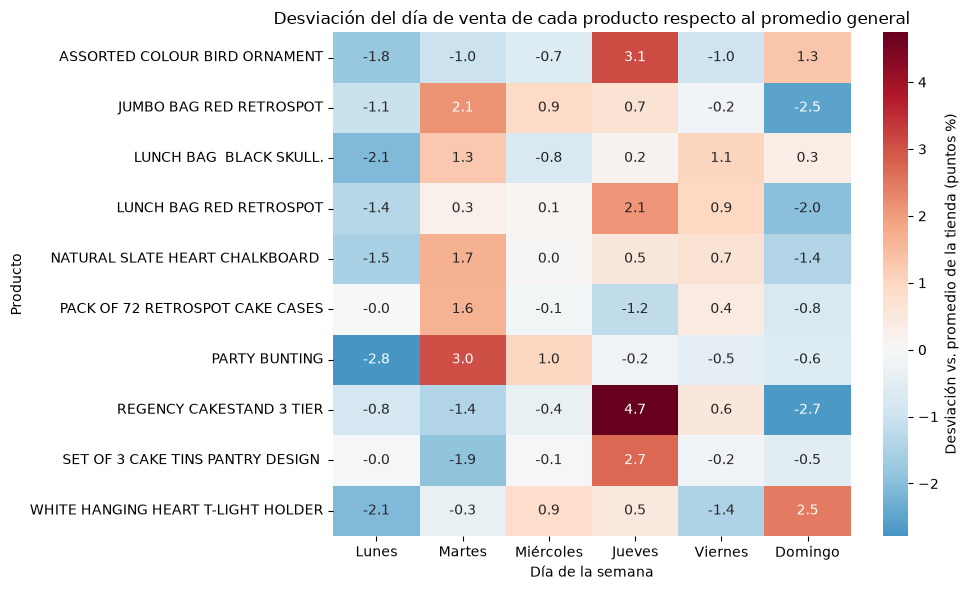

In [20]:
# Heatmap de los 10 productos más pedidos por día de la semana (sin sábado), en porcentaje
codigos_excluir = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'PADS', 'C2']
# Asegurar que consumer_data y columnas necesarias existan, sin sobrescribir si ya están
if 'consumer_data' not in globals():
    consumer_data = pd.read_excel('data/Online Retail.xlsx')

# Asegurar que Fecha_compra sea datetime
if not pd.api.types.is_datetime64_any_dtype(consumer_data.get('Fecha_compra')):
    consumer_data['Fecha_compra'] = pd.to_datetime(consumer_data['Fecha_compra'], errors='coerce')

# Crear Dia_semana si no existe
if 'Dia_semana' not in consumer_data.columns:
    dias_es = {0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',4:'Viernes',5:'Sábado',6:'Domingo'}
    consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_es)

# Filtrar códigos a excluir y eliminar sábados (según tu comentario "sin sábado")
datos_productos = consumer_data[~consumer_data['Cod_prod'].isin(codigos_excluir)].copy()
datos_productos = datos_productos[datos_productos['Dia_semana'] != 'Sábado']
top10 = datos_productos['Nombre_Producto'].value_counts().head(10).index
tabla = datos_productos[datos_productos['Nombre_Producto'].isin(top10)]

# % por producto y día (como ya tenías)
pct_producto_dia = pd.crosstab(tabla['Nombre_Producto'], tabla['Dia_semana'], normalize='index') * 100

# Línea base: % global por día, sobre TODA la tienda (sin filtrar a top10)
pct_global_dia = consumer_data['Dia_semana'].value_counts(normalize=True) * 100

# Índice de desviación: >0 significa que ese producto se vende más ese día de lo esperado
desviacion = pct_producto_dia.sub(pct_global_dia, axis=1)

productos_top10 = (
    datos_productos.groupby('Nombre_Producto')['Numero_factura']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

producto_semana_top10 = (
    datos_productos[datos_productos['Nombre_Producto'].isin(productos_top10)]
    .pivot_table(index='Nombre_Producto', columns='Dia_semana', values='Numero_factura', aggfunc='nunique', fill_value=0)
)

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Domingo']
desviacion = desviacion.reindex(columns=orden_dias)

producto_semana_top10_pct = producto_semana_top10.div(producto_semana_top10.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(desviacion, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Desviación vs. promedio de la tienda (puntos %)'})
plt.title('Desviación del día de venta de cada producto respecto al promedio general')
plt.xlabel('Día de la semana')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

Datos relevantes

In [23]:
fecha_corte = consumer_data['Fecha_compra'].max() + pd.Timedelta(days=1)

fecha_corte = consumer_data['Fecha_compra'].max() + pd.Timedelta(days=1)

if 'Monto' not in consumer_data.columns:
    consumer_data['Monto'] = consumer_data['Cantidad'] * consumer_data['Precio unitario']

rfm = consumer_data.groupby('Cod_Cliente').agg(
    Recency=('Fecha_compra', lambda x: (fecha_corte - x.max()).days),
    Frequency=('Numero_factura', 'nunique'),
    Monetary=('Monto', 'sum'),
    Diversidad_productos=('Cod_prod', 'nunique'),
    Pais=('País', 'first')
).reset_index()

rfm['Ticket_promedio'] = rfm['Monetary'] / rfm['Frequency']
if 'Estado de la compra' not in consumer_data.columns:
    consumer_data['Estado de la compra'] = np.where(
        consumer_data['Numero_factura'].astype(str).str.contains('C', case=False, na=False),
        'Cancelado',
        'Realizado'
    )

rfm['Tasa_cancelacion'] = consumer_data.groupby('Cod_Cliente')['Estado de la compra'] \
    .apply(lambda x: (x == 'Cancelado').mean()).values

rfm['Ticket_promedio'] = rfm['Monetary'] / rfm['Frequency']
rfm['Tasa_cancelacion'] = consumer_data.groupby('Cod_Cliente')['Estado de la compra'] \
    .apply(lambda x: (x == 'Cancelado').mean()).values

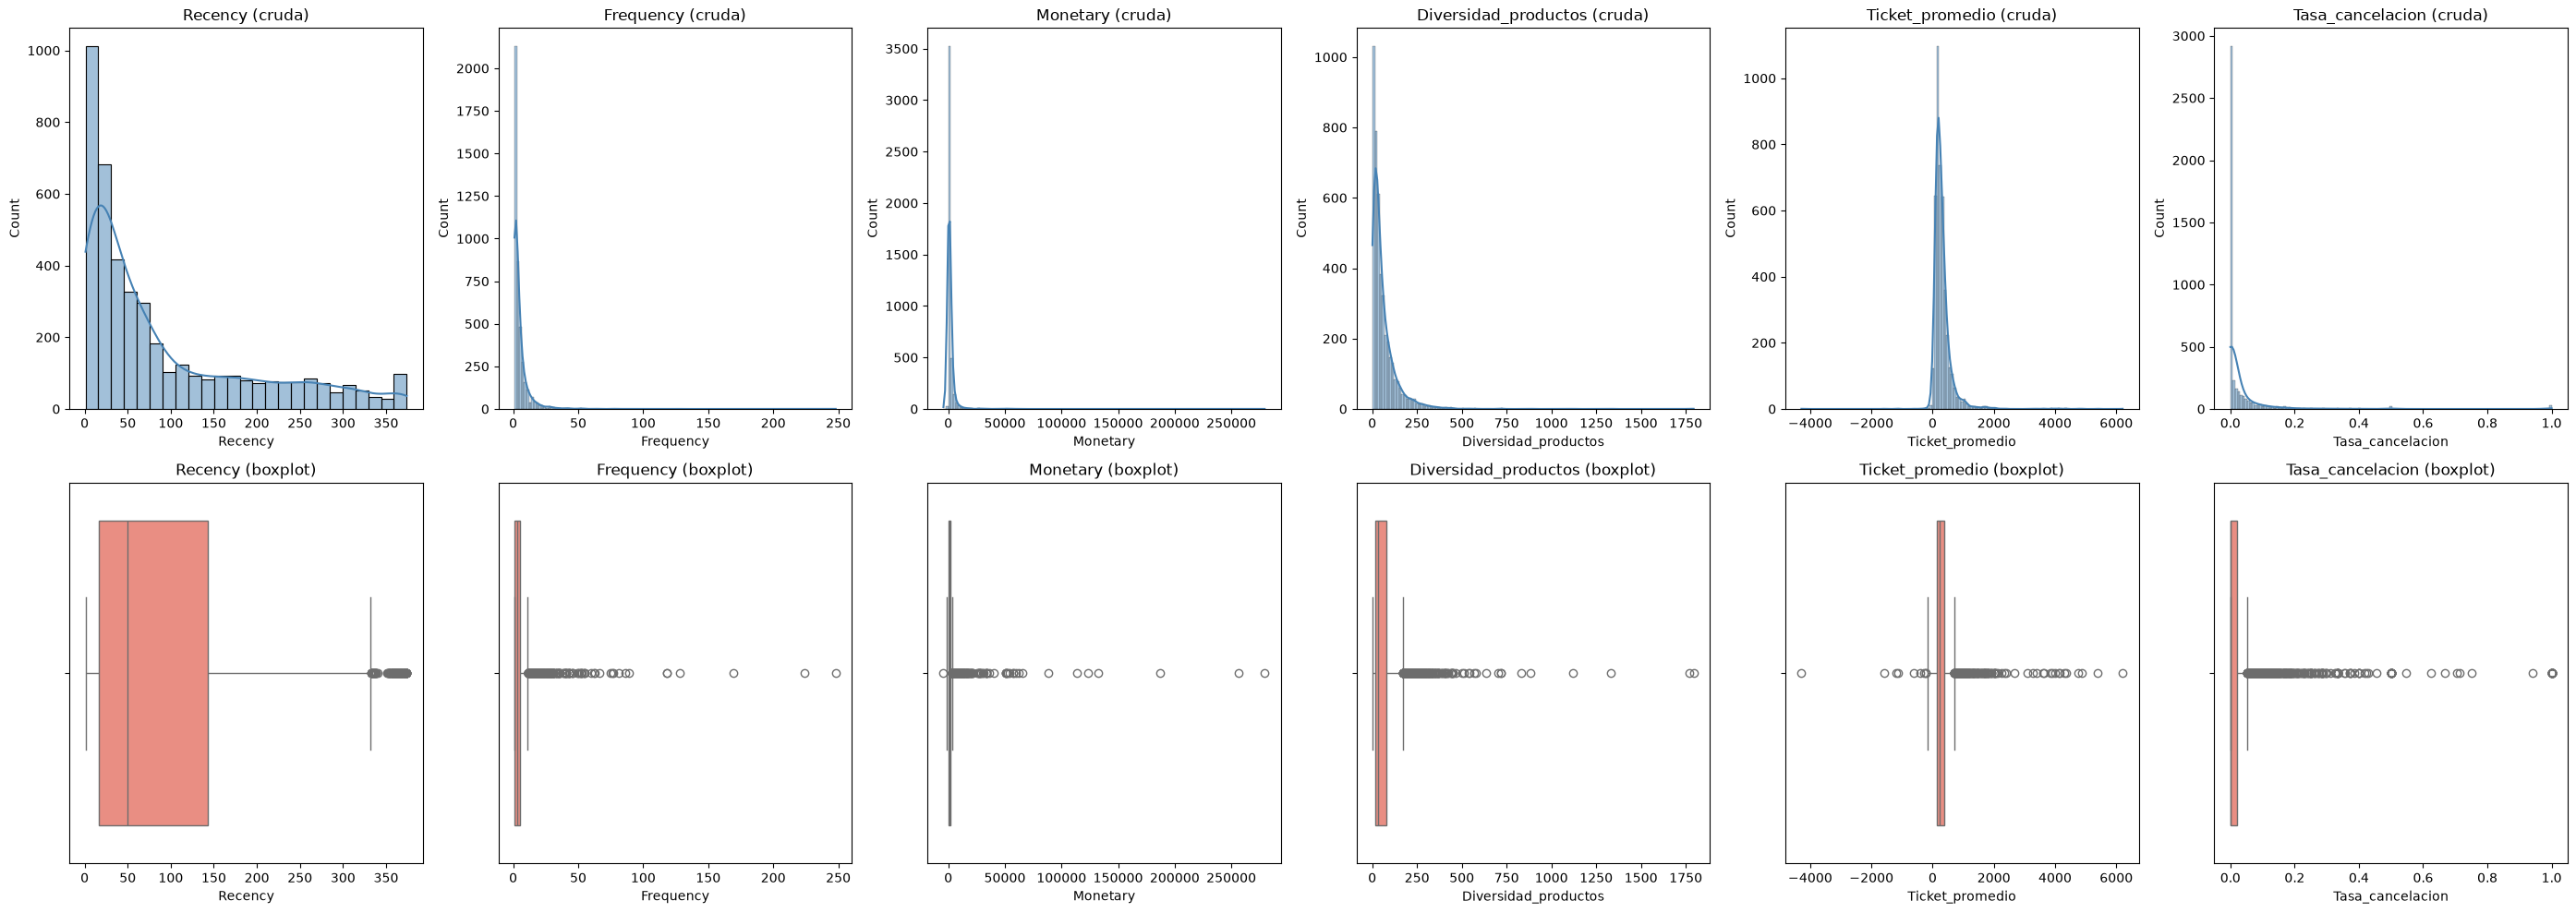

In [26]:

variables = ['Recency', 'Frequency', 'Monetary', 'Diversidad_productos', 'Ticket_promedio', 'Tasa_cancelacion']

fig, axes = plt.subplots(2, 6, figsize=(28, 10))

for i, col in enumerate(variables):
    # Fila 1: distribución cruda
    sns.histplot(rfm[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} (cruda)')

    # Fila 2: boxplot crudo, para ver outliers de un vistazo
    sns.boxplot(x=rfm[col], ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'{col} (boxplot)')

plt.tight_layout()
plt.show()

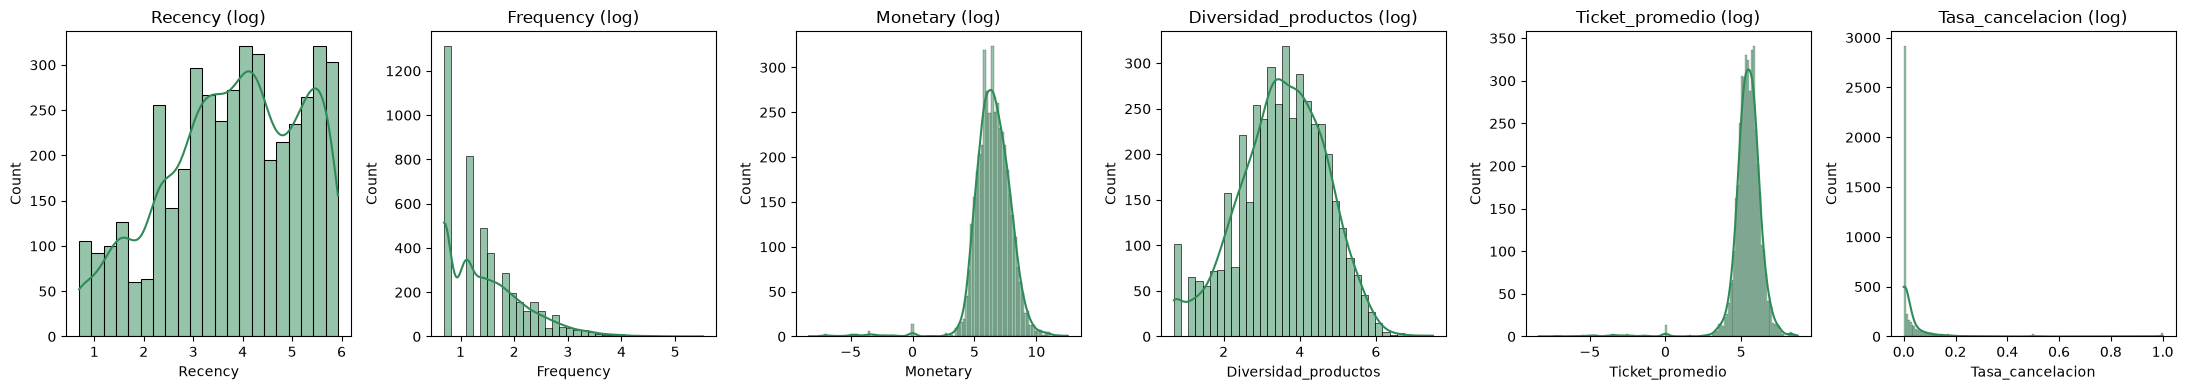

In [35]:
def log_signed(x):
    return np.sign(x) * np.log1p(np.abs(x))

rfm_log = rfm.copy()
for col in ['Recency', 'Frequency', 'Diversidad_productos']:
    rfm_log[col] = np.log1p(rfm[col])
for col in ['Monetary', 'Ticket_promedio']:
    rfm_log[col] = log_signed(rfm[col])

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, col in enumerate(variables):
    sns.histplot(rfm_log[col], kde=True, ax=axes[i], color='seagreen')
    axes[i].set_title(f'{col} (log)')
plt.tight_layout()
plt.show()

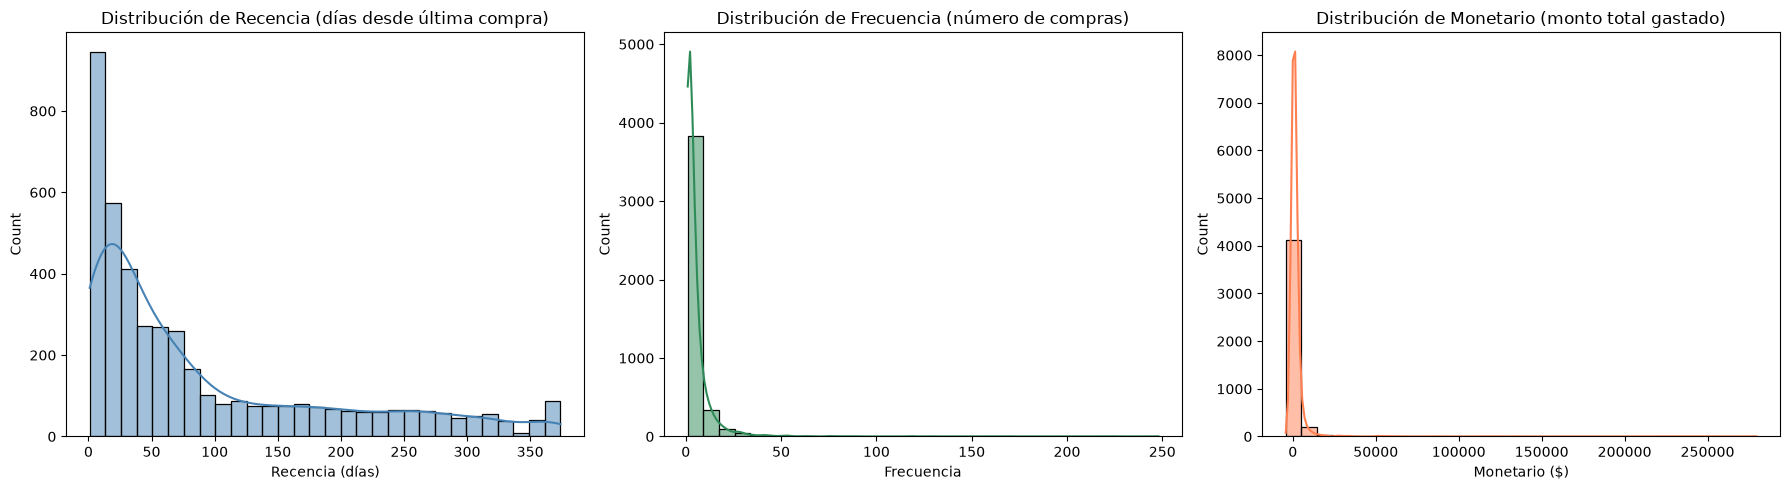

In [37]:
# Gráficos de distribuciones individuales RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recencia
sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Distribución de Recencia (días desde última compra)')
axes[0].set_xlabel('Recencia (días)')

# Frecuencia
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='seagreen', bins=30)
axes[1].set_title('Distribución de Frecuencia (número de compras)')
axes[1].set_xlabel('Frecuencia')

# Monetario
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='coral', bins=30)
axes[2].set_title('Distribución de Monetario (monto total gastado)')
axes[2].set_xlabel('Monetario ($)')

plt.tight_layout()
plt.show()


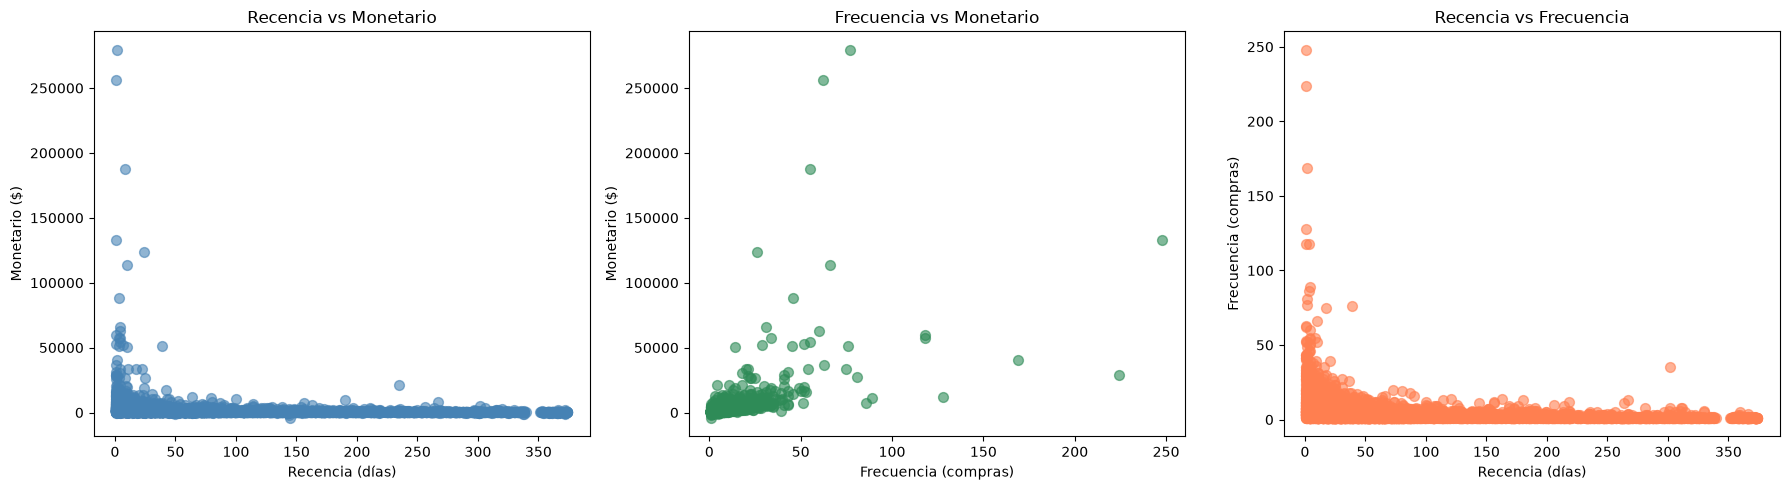

In [39]:
# Scatter plots de relaciones RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency vs Monetary
axes[0].scatter(rfm['Recency'], rfm['Monetary'], alpha=0.6, s=50, color='steelblue')
axes[0].set_xlabel('Recencia (días)')
axes[0].set_ylabel('Monetario ($)')
axes[0].set_title('Recencia vs Monetario')

# Frecuencia vs Monetary
axes[1].scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.6, s=50, color='seagreen')
axes[1].set_xlabel('Frecuencia (compras)')
axes[1].set_ylabel('Monetario ($)')
axes[1].set_title('Frecuencia vs Monetario')

# Recency vs Frecuencia
axes[2].scatter(rfm['Recency'], rfm['Frequency'], alpha=0.6, s=50, color='coral')
axes[2].set_xlabel('Recencia (días)')
axes[2].set_ylabel('Frecuencia (compras)')
axes[2].set_title('Recencia vs Frecuencia')

plt.tight_layout()
plt.show()


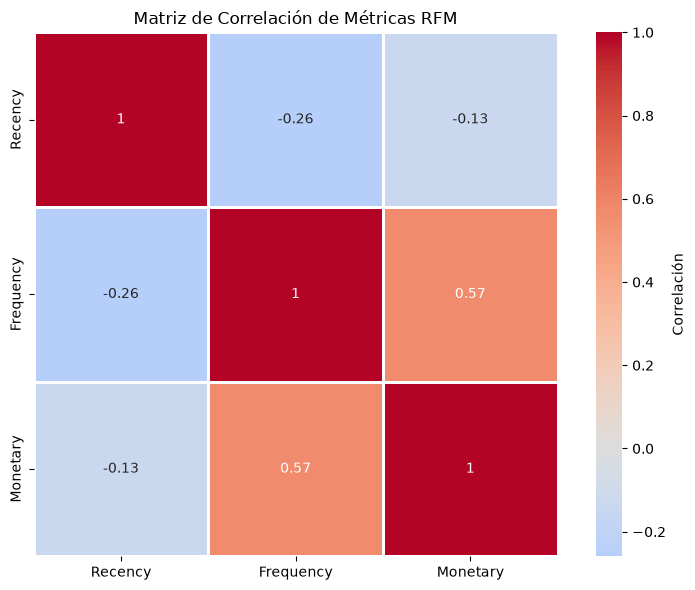

Estadísticas descriptivas de RFM:
           Recency    Frequency       Monetary
count  4372.000000  4372.000000    4372.000000
mean     92.047118     5.075480    1898.459701
std     100.765435     9.338754    8219.345141
min       1.000000     1.000000   -4287.630000
25%      17.000000     1.000000     293.362500
50%      50.000000     3.000000     648.075000
75%     143.000000     5.000000    1611.725000
max     374.000000   248.000000  279489.020000


In [51]:
# Matriz de correlación RFM
fig, ax = plt.subplots(figsize=(8, 6))
rfm_metricas = rfm[['Recency', 'Frequency', 'Monetary']]
correlacion = rfm_metricas.corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlación de Métricas RFM')
axes[0].set_xlabel('Recencia (días)')
axes[0].set_ylabel('Frecuencia (compras)')
plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("Estadísticas descriptivas de RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


# Introduciión a Algoritmos no supervisados